# 4. Exercise - Features

Due to issue with installing Gymnasium on my system, I am using the shared images from car racing for the subsequent tasks.

## B. Harris Corner Detector

In this exercise, the Harris corner detector is implemented for the Car Racing images. It is programmed from scratch using **numpy**, while the gradients are extracted using the Sobel operator of **OpenCV** and then verified with the implementation of the Harris corner detection from **OpenCV**. Detected corners and edges are visualized.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 


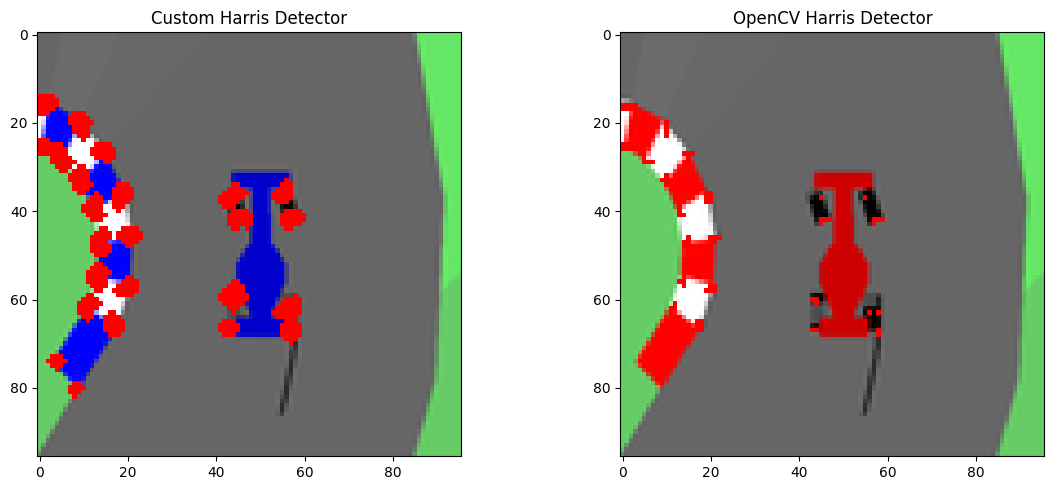

In [2]:
def numPy_harrisDetector(img):

    img = np.float32(img)
    Ix = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    Ixx = Ix * Ix
    Ixy = Ix * Iy
    Iyy = Iy * Iy

    # Applying gaussian filter to denoise
    Ixx = cv2.GaussianBlur(Ixx, (3, 3), sigmaX=1)
    Iyy = cv2.GaussianBlur(Iyy, (3, 3), sigmaX=1)
    Ixy = cv2.GaussianBlur(Ixy, (3, 3), sigmaX=1)

    # Harris Corner Detector calculation
    k = 0.04 
    detM = Ixx * Iyy - Ixy**2
    traceM = Ixx + Iyy
    R = detM - k * (traceM**2)

    # Threshold on R to detect corners
    R_max = R.max()
    corners = np.zeros_like(R)
    corners[R > 0.01 * R_max] = 255

    img_color = cv2.imread('images/car3.png',cv2.IMREAD_COLOR_RGB)

    for y, x in zip(*np.where(corners)):
       cv2.circle(img_color, (x, y), radius=1, color=(0, 0, 255), thickness=-1)

    return img_color

img_color = cv2.imread('images/car3.png',cv2.IMREAD_COLOR_RGB)
grayscale_img = cv2.imread('images/car3.png', cv2.IMREAD_GRAYSCALE)
custom_harris = numPy_harrisDetector(grayscale_img)

# Visualizing custom Harris corners
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Custom Harris Detector")
plt.imshow(cv2.cvtColor(custom_harris, cv2.COLOR_BGR2RGB))

openCV_harris = cv2.cornerHarris(grayscale_img, blockSize=2, ksize=3, k=0.04)
img_color[openCV_harris>0.05*openCV_harris.max()] = [255,0,0]

# Visualizing OpenCV Harris corners
plt.subplot(1, 2, 2)
plt.title("OpenCV Harris Detector")
plt.imshow(img_color)
plt.tight_layout()
plt.show()


## C. Laplacian of Gaussian and Difference of Gaussian

In this exercise, the Laplacian of Gaussian (LoG) and the Difference of Gaussians (DoG) are implemented. Similarly to task B, **OpenCV** functions are used for the gradient computation. Visualize the detected features and compare the results of Laplacian of Gaussian with the differences of Gaussian.

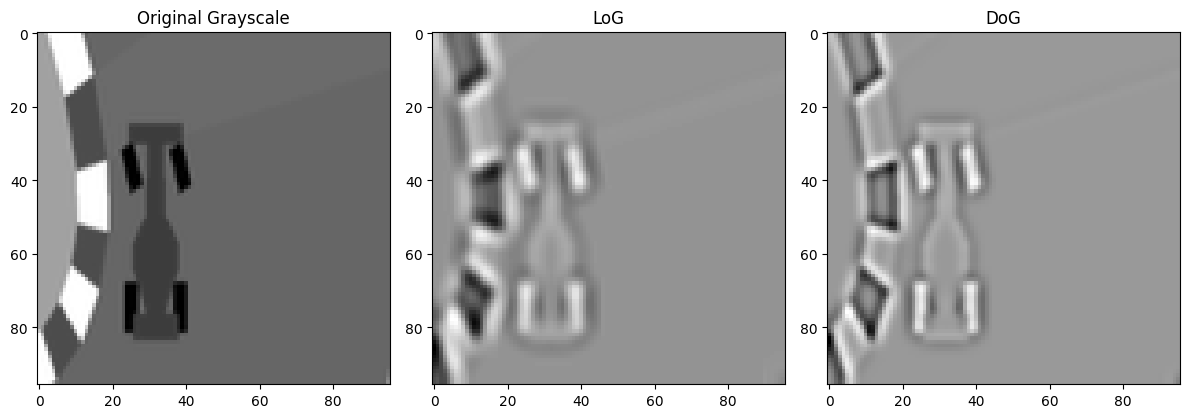

In [3]:
img = cv2.imread('images/car8.png', cv2.IMREAD_GRAYSCALE)
img = np.float32(img) / 255.0  # Normalize

# Implementing Laplacian of Gaussian (LoG)
gauss_blur = cv2.GaussianBlur(img, (9, 9), sigmaX=2)

laplacian_kernel = np.array([[0, 1, 0],
                             [1, -4, 1],
                             [0, 1, 0]], dtype=np.float32)

LoG = cv2.filter2D(gauss_blur, -1, laplacian_kernel)

#Implementing Difference of Gaussian
gaussian1 = cv2.GaussianBlur(img, (9, 9), sigmaX=1)
gaussian2 = cv2.GaussianBlur(img, (9, 9), sigmaX=2)

DoG = gaussian2 - gaussian1


plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title("Original Grayscale")
plt.imshow(img, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("LoG")
plt.imshow(LoG, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("DoG")
plt.imshow(DoG, cmap='gray')

plt.tight_layout()
plt.show()